<a href="https://colab.research.google.com/github/Saania-Shaik/sleep_quality_predictor/blob/main/Sleep_quality_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
print(" Upload your 'cleaned-dataset.csv' file:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print(f" Loaded {len(df)} records")

 Upload your 'cleaned-dataset.csv' file:


Saving cleaned-dataset.csv to cleaned-dataset.csv
 Loaded 374 records


In [3]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['BMI_Num'] = df['BMI Category'].map({'Normal': 0, 'Normal Weight': 1, 'Overweight': 2, 'Obese': 3})

df['Sleep_Quality'] = pd.cut(
    df['Quality of Sleep'],
    bins=[0, 5, 7, 10],
    labels=['Poor', 'Good', 'Excellent']
)

print("\n Target distribution:\n", df['Sleep_Quality'].value_counts())


 Target distribution:
 Sleep_Quality
Good         182
Excellent    180
Poor          12
Name: count, dtype: int64



📊 MODEL PERFORMANCE:
Test Accuracy: 0.98
Cross-Validation: 0.91 (+/- 0.25)

Classification Report:
               precision    recall  f1-score   support

   Excellent       1.00      0.98      0.99        45
        Good       0.96      1.00      0.98        46
        Poor       1.00      0.67      0.80         3

    accuracy                           0.98        94
   macro avg       0.99      0.88      0.92        94
weighted avg       0.98      0.98      0.98        94


 Feature Importance:
• Age: 0.00
• Sleep Duration: 0.25
• Physical Activity Level: 0.00
• Stress Level: 0.62
• Daily Steps: 0.12


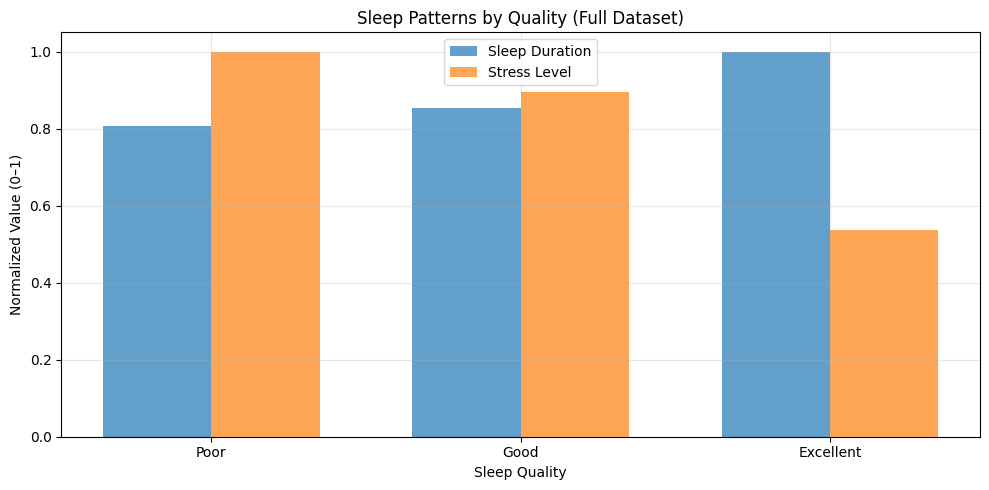

In [4]:

features = ['Age', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Daily Steps']
X = df[features]
y = df['Sleep_Quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = DecisionTreeClassifier(max_depth=4, min_samples_split=10, random_state=42)
model.fit(X_train, y_train)

X_test = pd.DataFrame(X_test, columns=features)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cv_scores = cross_val_score(model, X, y, cv=5)

print("\n📊 MODEL PERFORMANCE:")
print(f"Test Accuracy: {accuracy:.2f}")
print(f"Cross-Validation: {cv_scores.mean():.2f} (+/- {cv_scores.std()*2:.2f})")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\n Feature Importance:")
importance = model.feature_importances_
for f, imp in zip(features, importance):
    print(f"• {f}: {imp:.2f}")

quality_means = df.groupby('Sleep_Quality', observed=False)[['Sleep Duration', 'Stress Level']].mean()
quality_means_norm = quality_means.copy()
quality_means_norm['Sleep Duration'] /= quality_means['Sleep Duration'].max()
quality_means_norm['Stress Level'] /= quality_means['Stress Level'].max()

x = np.arange(len(quality_means_norm.index))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, quality_means_norm['Sleep Duration'], width, label='Sleep Duration', alpha=0.7)
plt.bar(x + width/2, quality_means_norm['Stress Level'], width, label='Stress Level', alpha=0.7)
plt.xlabel("Sleep Quality")
plt.ylabel("Normalized Value (0–1)")
plt.title("Sleep Patterns by Quality (Full Dataset)")
plt.xticks(x, quality_means_norm.index)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
print("\n📊 Full Dataset Averages:")
for q in ['Poor', 'Good', 'Excellent']:
    if q in df['Sleep_Quality'].unique():
        avg_sleep = df[df['Sleep_Quality'] == q]['Sleep Duration'].mean()
        avg_stress = df[df['Sleep_Quality'] == q]['Stress Level'].mean()
        print(f"  {q}: {avg_sleep:.1f} hrs sleep, {avg_stress:.1f}/10 stress")


📊 Full Dataset Averages:
  Poor: 6.2 hrs sleep, 7.4/10 stress
  Good: 6.6 hrs sleep, 6.6/10 stress
  Excellent: 7.7 hrs sleep, 4.0/10 stress



🌙 SLEEP HEALTH PREDICTOR
Age: 20
Sleep Duration (hours): 6
Physical Activity (0-100): 70
Stress Level (1-10): 6
Daily Steps: 4000

 Predicted Sleep Quality: Poor

 Personalized Recommendations:
• Try to get at least 7–8 hours of sleep daily.
• Avoid caffeine and screens before bed.
• Practice meditation or deep breathing.
• Maintain a fixed sleep schedule.

 Alerts:
• ⚠️ Increase steps to 6000–10,000 for better sleep.


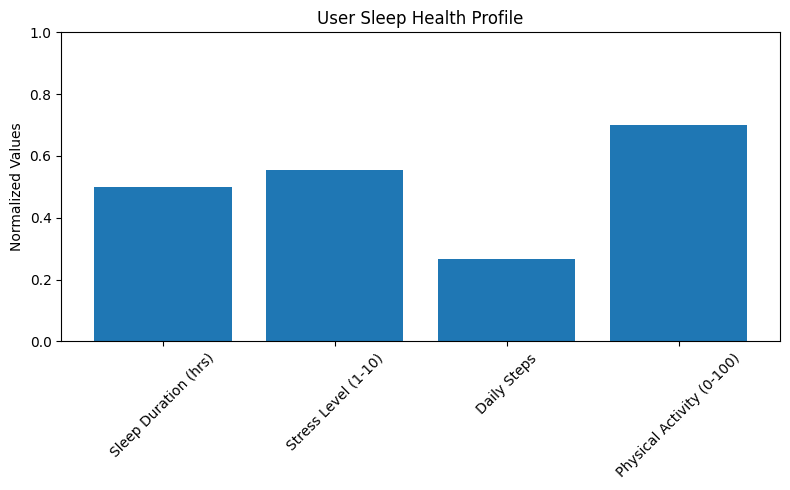

'Poor'

In [6]:
def predict_sleep():
    print("🌙 SLEEP HEALTH PREDICTOR")
    print("="*50)

    age = int(input("Age: "))
    sleep = float(input("Sleep Duration (hours): "))
    activity = int(input("Physical Activity (0-100): "))
    stress = int(input("Stress Level (1-10): "))
    steps = int(input("Daily Steps: "))

    input_df = pd.DataFrame([[age, sleep, activity, stress, steps]], columns=features)
    prediction = model.predict(input_df)[0]
    print(f"\n Predicted Sleep Quality: {prediction}")

    print("\n Personalized Recommendations:")
    if prediction == "Poor":
        print("• Try to get at least 7–8 hours of sleep daily.")
        print("• Avoid caffeine and screens before bed.")
        print("• Practice meditation or deep breathing.")
        print("• Maintain a fixed sleep schedule.")
    elif prediction == "Good":
        print("• Your sleep is good — maintain consistent habits.")
        print("• Avoid late meals and heavy screen time.")
        print("• Continue physical activity.")
    elif prediction == "Excellent":
        print("• Great sleep! Keep your routine consistent.")
        print("• Continue managing stress and staying active.")

    alerts = []
    if sleep < 6:
        alerts.append("⚠️ Your sleep is insufficient; aim for 7–8 hours.")
    if sleep > 9:
        alerts.append("⚠️ Oversleeping detected; check for fatigue or stress.")
    if stress > 7:
        alerts.append("⚠️ High stress detected. Consider meditation or relaxation.")
    if activity < 30:
        alerts.append("⚠️ Low physical activity! Try 30–45 mins daily.")
    if steps < 5000:
        alerts.append("⚠️ Increase steps to 6000–10,000 for better sleep.")

    if alerts:
        print("\n Alerts:")
        for alert in alerts:
            print("•", alert)

    disorders = []
    if sleep < 6 and stress > 7:
        disorders.append("⚠️ Possible Insomnia detected")
    if sleep < 6 and prediction == "Poor":
        disorders.append("⚠️ Sleep Deprivation / Poor Sleep pattern detected")
    if stress > 8 and sleep < 7:
        disorders.append("⚠️ Stress-related Sleep Issue detected")
    if activity < 30 and steps < 5000:
        disorders.append("⚠️ Low Activity affecting Sleep detected")

    if disorders:
        print("\n Sleep Disorder Alerts:")
        for d in disorders:
            print("•", d)

    user_data = {
        "Sleep Duration (hrs)": sleep,
        "Stress Level (1-10)": stress,
        "Daily Steps": steps,
        "Physical Activity (0-100)": activity
    }

    ranges = {
        "Sleep Duration (hrs)": (0, 12),
        "Stress Level (1-10)": (1, 10),
        "Daily Steps": (0, 15000),
        "Physical Activity (0-100)": (0, 100)
    }

    normalized_vals = [
        (val - mn) / (mx - mn)
        for (val, (mn, mx)) in zip(user_data.values(), ranges.values())
    ]

    plt.figure(figsize=(8, 5))
    plt.bar(user_data.keys(), normalized_vals)
    plt.ylim(0, 1)
    plt.title("User Sleep Health Profile")
    plt.ylabel("Normalized Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return prediction

print("\n" + "="*50)
predict_sleep()